In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import catboost as cgb
except:
    !uv pip install catboost
    import catboost as cgb

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


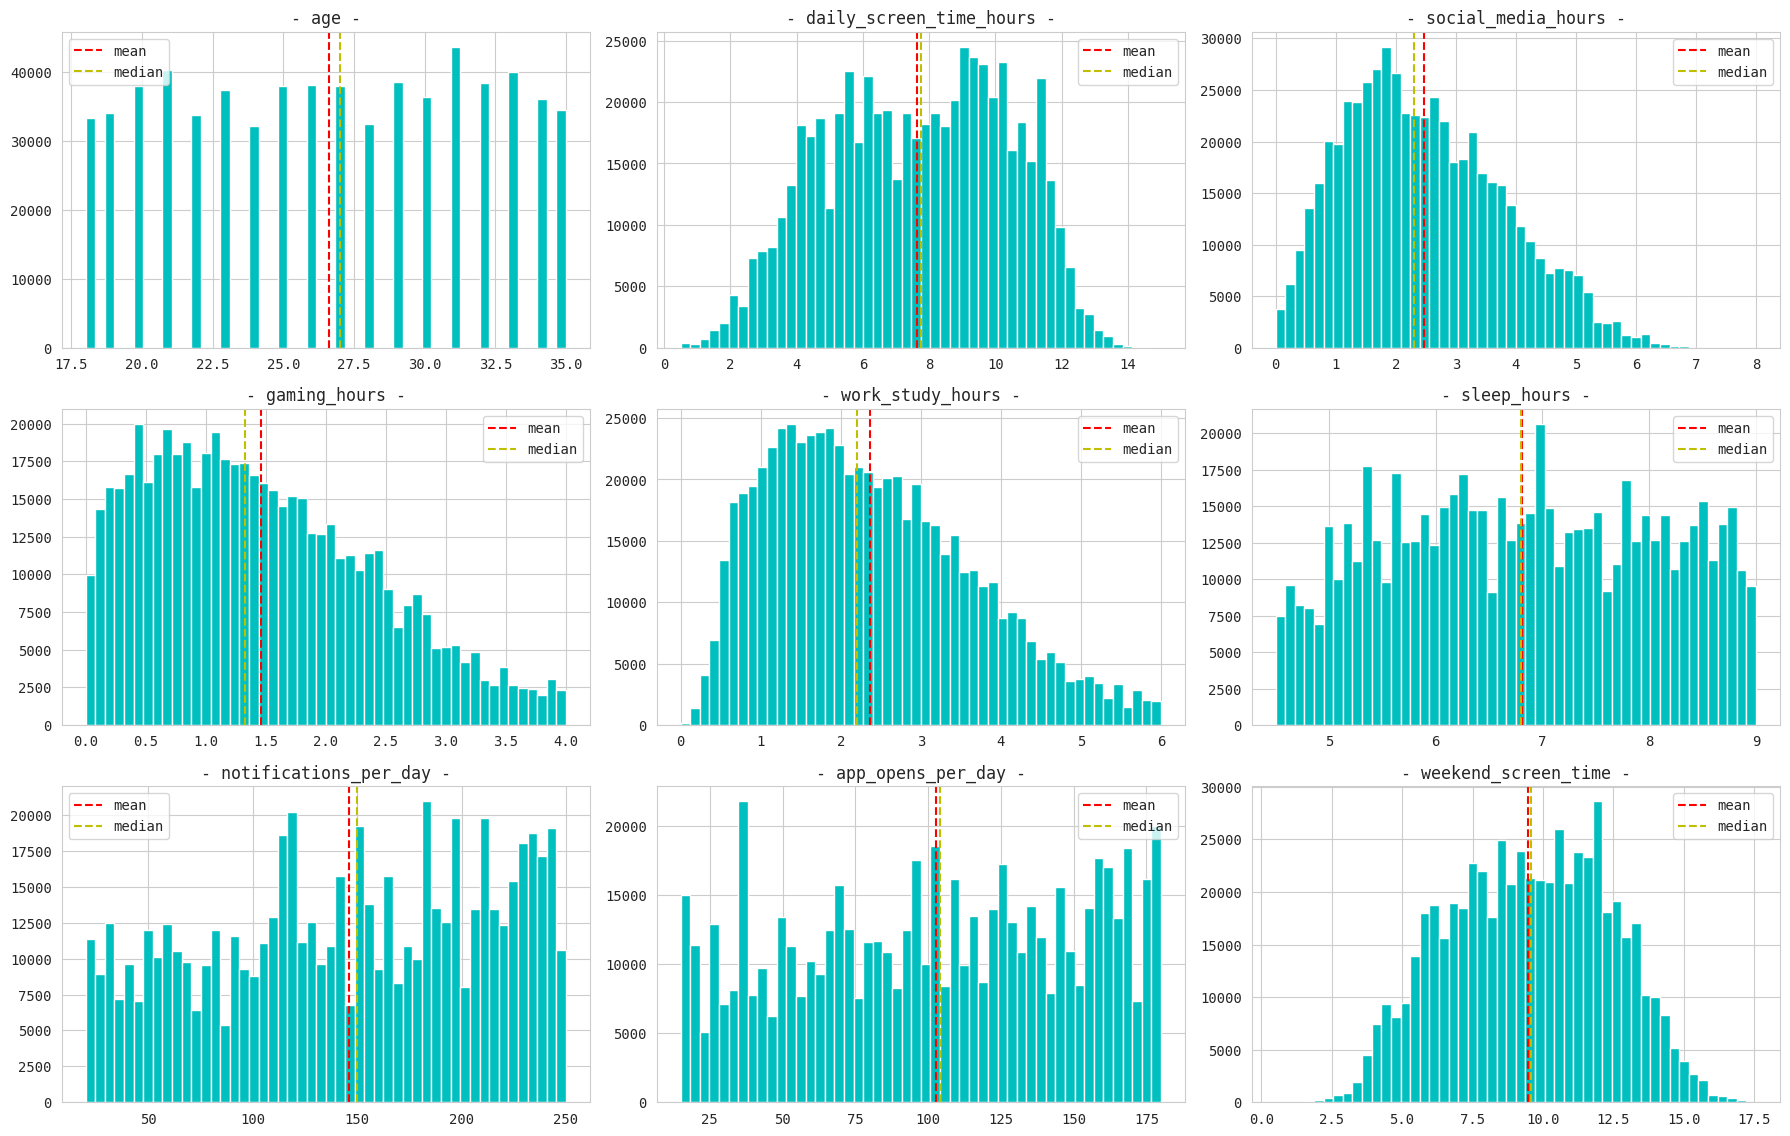

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Test
age,18,18
daily_screen_time_hours,1389,1349
social_media_hours,721,703
gaming_hours,401,401
work_study_hours,600,601
sleep_hours,451,451
notifications_per_day,231,231
app_opens_per_day,166,166
weekend_screen_time,1437,1404
gender,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
for col in NUMS:
    # print(f"\nRounding... ", end='')
    # for r in range(-2, 3):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')

    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in range(-3, 3):
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


DIGITS... age_digit_-3, age_digit_-2, age_digit_-1, age_digit_0, age_digit_1, age_digit_2, 
DIGITS... daily_screen_time_hours_digit_-3, daily_screen_time_hours_digit_-2, daily_screen_time_hours_digit_-1, daily_screen_time_hours_digit_0, daily_screen_time_hours_digit_1, daily_screen_time_hours_digit_2, 
DIGITS... social_media_hours_digit_-3, social_media_hours_digit_-2, social_media_hours_digit_-1, social_media_hours_digit_0, social_media_hours_digit_1, social_media_hours_digit_2, 
DIGITS... gaming_hours_digit_-3, gaming_hours_digit_-2, gaming_hours_digit_-1, gaming_hours_digit_0, gaming_hours_digit_1, gaming_hours_digit_2, 
DIGITS... work_study_hours_digit_-3, work_study_hours_digit_-2, work_study_hours_digit_-1, work_study_hours_digit_0, work_study_hours_digit_1, work_study_hours_digit_2, 
DIGITS... sleep_hours_digit_-3, sleep_hours_digit_-2, sleep_hours_digit_-1, sleep_hours_digit_0, sleep_hours_digit_1, sleep_hours_digit_2, 
DIGITS... notifications_per_day_digit_-3, notifications_p

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

age_digit_-3                         2
age_digit_-2                         2
age_digit_-1                         4
age_digit_0                         11
age_digit_1                          2
age_digit_2                          2
daily_screen_time_hours_digit_-3     2
daily_screen_time_hours_digit_-2     2
daily_screen_time_hours_digit_-1     3
daily_screen_time_hours_digit_0     11
daily_screen_time_hours_digit_1     11
daily_screen_time_hours_digit_2     11
social_media_hours_digit_-3          2
social_media_hours_digit_-2          2
social_media_hours_digit_-1          2
social_media_hours_digit_0          10
social_media_hours_digit_1          11
social_media_hours_digit_2          11
gaming_hours_digit_-3                2
gaming_hours_digit_-2                2
gaming_hours_digit_-1                2
gaming_hours_digit_0                 6
gaming_hours_digit_1                11
gaming_hours_digit_2                11
work_study_hours_digit_-3            2
work_study_hours_digit_-2

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
## -- Frequency encoding --
FREQ_COLS = []

print(f"\nCreating frequencies... ", end='')
for col in NUMS: # 'Position_Change'
    freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test]: # , orig
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    FREQ_COLS.append(n)

print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
train[FREQ_COLS]


Creating frequencies... age_freq, daily_screen_time_hours_freq, social_media_hours_freq, gaming_hours_freq, work_study_hours_freq, sleep_hours_freq, notifications_per_day_freq, app_opens_per_day_freq, weekend_screen_time_freq, 
✓ Total frequency features: 9


,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq
0,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754
1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000
2,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919
3,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735
4,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638
...,...,...,...,...,...,...,...,...,...
691364,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169
691365,0.057368,0.001341,0.004068,0.002797,0.000549,0.004163,0.005939,0.011147,0.003234
691366,0.000000,0.000000,0.000000,0.000000,0.003335,0.001894,0.000000,0.002395,0.001529
691367,0.051199,0.001638,0.002188,0.002592,0.004219,0.001178,0.003195,0.003110,0.002057


In [17]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [18]:
# ## -- Arithmetic interactions --
# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [19]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [22]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# train

In [23]:
## -- Duplicate all numerics as categories --
CATS_2 = []

for c in NUMS:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    orig[n]  = orig[c].copy()
    CATS_2.append(n)

    ## -- Factorize -- 
    combined  = pd.concat([train[n], test[n] , orig[n]]) #
    cat_v = combined.factorize()[0]
    # cat_v = pd.Series(cat_v).astype(str)
    train[n] = cat_v[:len(train)].astype('int32')
    test[n]  = cat_v[len(train):len(train)+len(test)].astype('int32')
    orig[n]  = cat_v[len(train)+len(test):].astype('int32')

del combined, cat_v
print(f"Nums to Cats: {len(CATS_2)}")

CATS_2

Nums to Cats: 9


['cat_age',
 'cat_daily_screen_time_hours',
 'cat_social_media_hours',
 'cat_gaming_hours',
 'cat_work_study_hours',
 'cat_sleep_hours',
 'cat_notifications_per_day',
 'cat_app_opens_per_day',
 'cat_weekend_screen_time']

In [24]:
## -- Factorize combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    cat_v = combined.factorize()[0]
    # cat_v = pd.Series(cat_v).astype(str)
    train[c] = cat_v[:len(train)].astype('int32')
    test[c]  = cat_v[len(train):len(train)+len(test)].astype('int32')
    orig[c]  = cat_v[len(train)+len(test):].astype('int32')

del combined, cat_v
print("Label encoding complete!")

Label encoding complete!


In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 84


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_digit_-3,age_digit_-2,age_digit_-1,age_digit_0,age_digit_1,age_digit_2,daily_screen_time_hours_digit_-3,daily_screen_time_hours_digit_-2,daily_screen_time_hours_digit_-1,daily_screen_time_hours_digit_0,daily_screen_time_hours_digit_1,daily_screen_time_hours_digit_2,social_media_hours_digit_-3,social_media_hours_digit_-2,social_media_hours_digit_-1,social_media_hours_digit_0,social_media_hours_digit_1,social_media_hours_digit_2,gaming_hours_digit_-3,gaming_hours_digit_-2,gaming_hours_digit_-1,gaming_hours_digit_0,gaming_hours_digit_1,gaming_hours_digit_2,work_study_hours_digit_-3,work_study_hours_digit_-2,work_study_hours_digit_-1,work_study_hours_digit_0,work_study_hours_digit_1,work_study_hours_digit_2,sleep_hours_digit_-3,sleep_hours_digit_-2,sleep_hours_digit_-1,sleep_hours_digit_0,sleep_hours_digit_1,sleep_hours_digit_2,notifications_per_day_digit_-3,notifications_per_day_digit_-2,notifications_per_day_digit_-1,notifications_per_day_digit_0,notifications_per_day_digit_1,notifications_per_day_digit_2,app_opens_per_day_digit_-3,app_opens_per_day_digit_-2,app_opens_per_day_digit_-1,app_opens_per_day_digit_0,app_opens_per_day_digit_1,app_opens_per_day_digit_2,weekend_screen_time_digit_-3,weekend_screen_time_digit_-2,weekend_screen_time_digit_-1,weekend_screen_time_digit_0,weekend_screen_time_digit_1,weekend_screen_time_digit_2,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1,0,0,2,4,0,0,-1,-1,-1,-1,-1,-1,0,0,0,1,8,3,0,0,0,1,5,9,0,0,0,2,1,1,0,0,0,7,4,6,0,1,2,2,0,0,0,0,3,8,0,0,0,0,0,8,6,3,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754,0,-1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0,0,0,1,9,0,0,0,0,0,5,9,7,0,0,0,1,0,8,-1,-1,-1,-1,-1,-1,0,0,0,3,0,3,0,0,0,8,2,2,0,0,7,6,0,0,0,0,1,9,0,0,-1,-1,-1,-1,-1,-1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000,1,0,1,-1,1,1,1,1,-1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0,0,0,1,8,0,0,0,0,0,5,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,0,6,2,5,0,1,3,4,0,0,0,0,6,0,0,0,0,0,0,7,4,7,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919,2,1,-1,-1,-1,2,2,2,1
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1,0,0,2,1,0,0,0,0,0,6,4,2,0,0,0,1,2,6,0,0,0,1,4,2,0,0,0,3,3,6,0,0,0,8,8,5,0,1,1,2,0,0,0,0,9,4,0,0,0,0,0,8,6,6,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735,3,2,2,1,2,3,3,3,2
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1,0,0,2,6,0,0,0,0,1,1,2,0,0,0,0,1,8,7,0,0,0,2,8,1,0,0,0,1,9,5,0,0,0,5,2,5,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,1,3,3,9,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638,4,3,3,2,3,4,-1,-1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1,0,0,2,2,0,0,0,0,1,0,7,8,0,0,0,3,2,5,0,0,0,1,5,7,0,0,0,1,6,5,0,0,0,7,7,1,0,0,8,6,0,0,0,0,9,4,0,0,0,0,1,2,8,9,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169,12,783,374,145,109,88,168,3,786
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,22

# ML TRAINING

In [26]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols,
               use_orig=False, early_stop=100, print_every=200):
    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits}", end=" | ")

        ## -- Split data for the current fold
        X_train, X_valid = X.loc[train_idx], X.loc[val_idx]
        y_train, y_valid = y.loc[train_idx], y.loc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
                fill_nan=True,
            )

        # ## -- TE Opt1. -> Using CUSTOM -- 
        # te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        all_categorical = cat_cols.copy()
        
        combined = pd.concat([X_train, X_valid, X_test])
        for c in all_categorical:
            combined[c] = combined[c].astype(str)
        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=10_000,
            eval_set=dval,
            early_stopping_rounds=early_stop,
            verbose=print_every,
        )

        feat_importances.append(model.get_feature_importance(prettified=True))

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1].ravel()
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1].ravel() / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del dtrain, dval, dtest
        # gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {score:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [27]:
VER = "cat_TEboost(84)_"
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS + CATS_2

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_digit_-3,age_digit_-2,age_digit_-1,age_digit_0,age_digit_1,age_digit_2,daily_screen_time_hours_digit_-3,daily_screen_time_hours_digit_-2,daily_screen_time_hours_digit_-1,daily_screen_time_hours_digit_0,daily_screen_time_hours_digit_1,daily_screen_time_hours_digit_2,social_media_hours_digit_-3,social_media_hours_digit_-2,social_media_hours_digit_-1,social_media_hours_digit_0,social_media_hours_digit_1,social_media_hours_digit_2,gaming_hours_digit_-3,gaming_hours_digit_-2,gaming_hours_digit_-1,gaming_hours_digit_0,gaming_hours_digit_1,gaming_hours_digit_2,work_study_hours_digit_-3,work_study_hours_digit_-2,work_study_hours_digit_-1,work_study_hours_digit_0,work_study_hours_digit_1,work_study_hours_digit_2,sleep_hours_digit_-3,sleep_hours_digit_-2,sleep_hours_digit_-1,sleep_hours_digit_0,sleep_hours_digit_1,sleep_hours_digit_2,notifications_per_day_digit_-3,notifications_per_day_digit_-2,notifications_per_day_digit_-1,notifications_per_day_digit_0,notifications_per_day_digit_1,notifications_per_day_digit_2,app_opens_per_day_digit_-3,app_opens_per_day_digit_-2,app_opens_per_day_digit_-1,app_opens_per_day_digit_0,app_opens_per_day_digit_1,app_opens_per_day_digit_2,weekend_screen_time_digit_-3,weekend_screen_time_digit_-2,weekend_screen_time_digit_-1,weekend_screen_time_digit_0,weekend_screen_time_digit_1,weekend_screen_time_digit_2,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1,0,0,2,4,0,0,-1,-1,-1,-1,-1,-1,0,0,0,1,8,3,0,0,0,1,5,9,0,0,0,2,1,1,0,0,0,7,4,6,0,1,2,2,0,0,0,0,3,8,0,0,0,0,0,8,6,3,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754,0,-1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0,0,0,1,9,0,0,0,0,0,5,9,7,0,0,0,1,0,8,-1,-1,-1,-1,-1,-1,0,0,0,3,0,3,0,0,0,8,2,2,0,0,7,6,0,0,0,0,1,9,0,0,-1,-1,-1,-1,-1,-1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000,1,0,1,-1,1,1,1,1,-1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0,0,0,1,8,0,0,0,0,0,5,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,0,6,2,5,0,1,3,4,0,0,0,0,6,0,0,0,0,0,0,7,4,7,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919,2,1,-1,-1,-1,2,2,2,1
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1,0,0,2,1,0,0,0,0,0,6,4,2,0,0,0,1,2,6,0,0,0,1,4,2,0,0,0,3,3,6,0,0,0,8,8,5,0,1,1,2,0,0,0,0,9,4,0,0,0,0,0,8,6,6,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735,3,2,2,1,2,3,3,3,2
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1,0,0,2,6,0,0,0,0,1,1,2,0,0,0,0,1,8,7,0,0,0,2,8,1,0,0,0,1,9,5,0,0,0,5,2,5,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,1,3,3,9,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638,4,3,3,2,3,4,-1,-1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1,0,0,2,2,0,0,0,0,1,0,7,8,0,0,0,3,2,5,0,0,0,1,5,7,0,0,0,1,6,5,0,0,0,7,7,1,0,0,8,6,0,0,0,0,9,4,0,0,0,0,1,2,8,9,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169,12,783,374,145,109,88,168,3,786
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,22

In [28]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# OUT_LOOP = [0.5, 1.0]
# INN_LOOP = [4.0]
# p_name   = ['BT', 'L1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': outer,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.05,
#             # 'depth': 6,
#             # 'l2_leaf_reg': REGULATE,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [29]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('CATBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score-5e-8, score, ha='right', va='baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

In [30]:
LR = 0.03
# L2_REG = 2.5
EARLY_STOP   = 100
PRINT_STEPS  = 1000
USE_ORIGINAL = False

In [31]:
## ========================== BAYESIAN 
bayes_params = {
    'boosting_type': 'Plain',
    'grow_policy': 'SymmetricTree',
    'bootstrap_type': 'Bayesian',
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bayes_params,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_TEboost(84)_bayes =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9244116	best: 0.9244116 (0)	total: 268ms	remaining: 44m 41s
1000:	test: 0.9645486	best: 0.9645486 (1000)	total: 58.9s	remaining: 8m 49s
2000:	test: 0.9657598	best: 0.9657598 (2000)	total: 1m 59s	remaining: 7m 57s
3000:	test: 0.9662089	best: 0.9662089 (3000)	total: 3m	remaining: 7m 1s
4000:	test: 0.9664538	best: 0.9664538 (4000)	total: 4m 2s	remaining: 6m 3s
5000:	test: 0.9665881	best: 0.9665881 (4998)	total: 5m 5s	remaining: 5m 5s
6000:	test: 0.9666821	best: 0.9666829 (5986)	total: 6m 8s	remaining: 4m 5s
bestTest = 0.9667288661
bestIteration = 6760
Shrink model to first 6761 iterations.
 • Fold 1 AUC: 0.966729

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9243618	best: 0.9243618 (0)	total: 80.5ms	remaining: 13m 25s
1000:	test: 0.9651943	best: 0.9651943 (1000)	total: 59.7s	remaining: 8m 56s
2000:	test: 0.9664877	best: 0.9664877 (2000)	total: 2m	remaining: 8m
3000:	test: 0.9669873	best: 0.9669873 (3000)	total: 3m 1s	remaining: 7m 2s
4000:	test: 0.9672563	best: 0.9672563 (4000)	total: 4m 2s	remaining: 6m 3s
5000:	test: 0.9673933	best: 0.9673933 (4998)	total: 5m 4s	remaining: 5m 4s
6000:	test: 0.9674874	best: 0.9674875 (5998)	total: 6m 7s	remaining: 4m 4s
7000:	test: 0.9675568	best: 0.9675571 (6999)	total: 7m 10s	remaining: 3m 4s
bestTest = 0.9675782025
bestIteration = 7508
Shrink model to first 7509 iterations.
 • Fold 2 AUC: 0.967578

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9254509	best: 0.9254509 (0)	total: 80.8ms	remaining: 13m 27s
1000:	test: 0.9654866	best: 0.9654866 (1000)	total: 59.3s	remaining: 8m 52s
2000:	test: 0.9666166	best: 0.9666166 (2000)	total: 1m 59s	remaining: 7m 57s
3000:	test: 0.9670559	best: 0.9670559 (3000)	total: 3m	remaining: 7m 1s
4000:	test: 0.9672930	best: 0.9672940 (3987)	total: 4m 2s	remaining: 6m 3s
5000:	test: 0.9674425	best: 0.9674425 (5000)	total: 5m 4s	remaining: 5m 4s
6000:	test: 0.9675342	best: 0.9675342 (6000)	total: 6m 7s	remaining: 4m 4s
7000:	test: 0.9675831	best: 0.9675837 (6996)	total: 7m 10s	remaining: 3m 4s
8000:	test: 0.9676231	best: 0.9676257 (7935)	total: 8m 13s	remaining: 2m 3s
bestTest = 0.9676256776
bestIteration = 7935
Shrink model to first 7936 iterations.
 • Fold 3 AUC: 0.967626

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9258932	best: 0.9258932 (0)	total: 80.7ms	remaining: 13m 27s
1000:	test: 0.9657608	best: 0.9657608 (1000)	total: 59.7s	remaining: 8m 56s
2000:	test: 0.9670471	best: 0.9670471 (2000)	total: 2m	remaining: 8m
3000:	test: 0.9675217	best: 0.9675217 (3000)	total: 3m 1s	remaining: 7m 2s
4000:	test: 0.9677535	best: 0.9677535 (3999)	total: 4m 2s	remaining: 6m 4s
5000:	test: 0.9679046	best: 0.9679065 (4993)	total: 5m 5s	remaining: 5m 4s
6000:	test: 0.9680104	best: 0.9680110 (5989)	total: 6m 7s	remaining: 4m 5s
7000:	test: 0.9680890	best: 0.9680890 (6988)	total: 7m 10s	remaining: 3m 4s
8000:	test: 0.9681605	best: 0.9681605 (8000)	total: 8m 13s	remaining: 2m 3s
bestTest = 0.968182385
bestIteration = 8616
Shrink model to first 8617 iterations.
 • Fold 4 AUC: 0.968182

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9250739	best: 0.9250739 (0)	total: 81ms	remaining: 13m 29s
1000:	test: 0.9647114	best: 0.9647114 (1000)	total: 59.4s	remaining: 8m 54s
2000:	test: 0.9661226	best: 0.9661226 (1999)	total: 1m 59s	remaining: 7m 59s
3000:	test: 0.9666139	best: 0.9666139 (3000)	total: 3m 1s	remaining: 7m 2s
4000:	test: 0.9668577	best: 0.9668589 (3994)	total: 4m 2s	remaining: 6m 3s
5000:	test: 0.9669950	best: 0.9669958 (4986)	total: 5m 4s	remaining: 5m 4s
6000:	test: 0.9670817	best: 0.9670839 (5957)	total: 6m 7s	remaining: 4m 4s
7000:	test: 0.9671317	best: 0.9671329 (6943)	total: 7m 9s	remaining: 3m 4s
bestTest = 0.9671570063
bestIteration = 7358
Shrink model to first 7359 iterations.
 • Fold 5 AUC: 0.967157

5-FOLD CV: cat_TEboost(84)_bayes
 • Fold 1 AUC: 0.966729
 • Fold 2 AUC: 0.967578
 • Fold 3 AUC: 0.967626
 • Fold 4 AUC: 0.968182
 • Fold 5 AUC: 0.967157
-------------------------------------------------|
Overall AUC: 0.967453
Average AUC: 0.967454 ± 0.000488
----------------------------------

In [32]:
# ==================================================
# 5-FOLD CV: cat_TE_bayes
# ==================================================
#  • Fold 1 AUC: 0.966638
#  • Fold 2 AUC: 0.967381
#  • Fold 3 AUC: 0.967625
#  • Fold 4 AUC: 0.967941
#  • Fold 5 AUC: 0.967004
# -------------------------------------------------|
# Overall AUC: 0.967317
# Average AUC: 0.967318 ± 0.000458
# -------------------------------------------------|
# 17.24 mins

In [33]:
# ## =========================== MVS -- OOM issues
# mvs_params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     # 'learning_rate': LR,
#     # ---------------------------------
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     # 'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     # 'depth': 6,
#     # 'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'thread_count': -1,
#     'allow_writing_files': False,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = VER+"cat_mvs"

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=mvs_params,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     use_orig=USE_ORIGINAL,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
# )

In [34]:
## =========================== BERNOULLI
bern_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Plain",
    'grow_policy': "Depthwise",
    'bootstrap_type': "Bernoulli",
    # ---------------------------------
    # 'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.7,
    'min_data_in_leaf': 40,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "bern"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bern_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS
)


===== Starting CV: cat_TEboost(84)_bern =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9373032	best: 0.9373032 (0)	total: 167ms	remaining: 27m 48s
1000:	test: 0.9646007	best: 0.9646007 (1000)	total: 25.2s	remaining: 3m 46s
2000:	test: 0.9654992	best: 0.9654992 (2000)	total: 50.3s	remaining: 3m 21s
3000:	test: 0.9658198	best: 0.9658203 (2999)	total: 1m 15s	remaining: 2m 56s
4000:	test: 0.9659534	best: 0.9659534 (4000)	total: 1m 41s	remaining: 2m 31s
bestTest = 0.9659589529
bestIteration = 4072
Shrink model to first 4073 iterations.
 • Fold 1 AUC: 0.965959

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9378496	best: 0.9378496 (0)	total: 41.2ms	remaining: 6m 51s
1000:	test: 0.9653270	best: 0.9653270 (1000)	total: 25.3s	remaining: 3m 47s
2000:	test: 0.9663054	best: 0.9663054 (2000)	total: 50.2s	remaining: 3m 20s
3000:	test: 0.9665862	best: 0.9665870 (2995)	total: 1m 15s	remaining: 2m 56s
4000:	test: 0.9667274	best: 0.9667274 (4000)	total: 1m 41s	remaining: 2m 31s
bestTest = 0.9667676687
bestIteration = 4457
Shrink model to first 4458 iterations.
 • Fold 2 AUC: 0.966768

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9389421	best: 0.9389421 (0)	total: 42ms	remaining: 6m 59s
1000:	test: 0.9656769	best: 0.9656769 (1000)	total: 25.4s	remaining: 3m 47s
2000:	test: 0.9664962	best: 0.9664962 (2000)	total: 50s	remaining: 3m 20s
3000:	test: 0.9667710	best: 0.9667713 (2998)	total: 1m 14s	remaining: 2m 54s
bestTest = 0.9668024182
bestIteration = 3248
Shrink model to first 3249 iterations.
 • Fold 3 AUC: 0.966802

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9388748	best: 0.9388748 (0)	total: 39.2ms	remaining: 6m 32s
1000:	test: 0.9658601	best: 0.9658602 (999)	total: 24.3s	remaining: 3m 38s
2000:	test: 0.9667954	best: 0.9667954 (2000)	total: 48s	remaining: 3m 11s
3000:	test: 0.9671333	best: 0.9671333 (3000)	total: 1m 12s	remaining: 2m 49s
4000:	test: 0.9672956	best: 0.9672967 (3989)	total: 1m 37s	remaining: 2m 25s
5000:	test: 0.9673425	best: 0.9673437 (4952)	total: 2m 2s	remaining: 2m 2s
bestTest = 0.9673500657
bestIteration = 5212
Shrink model to first 5213 iterations.
 • Fold 4 AUC: 0.967350

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9381591	best: 0.9381591 (0)	total: 43.7ms	remaining: 7m 17s
1000:	test: 0.9650143	best: 0.9650143 (1000)	total: 25.4s	remaining: 3m 48s
2000:	test: 0.9659685	best: 0.9659685 (2000)	total: 50.2s	remaining: 3m 20s
3000:	test: 0.9662499	best: 0.9662499 (3000)	total: 1m 15s	remaining: 2m 55s
4000:	test: 0.9663744	best: 0.9663756 (3922)	total: 1m 40s	remaining: 2m 30s
bestTest = 0.9664046764
bestIteration = 4271
Shrink model to first 4272 iterations.
 • Fold 5 AUC: 0.966405

5-FOLD CV: cat_TEboost(84)_bern
 • Fold 1 AUC: 0.965959
 • Fold 2 AUC: 0.966768
 • Fold 3 AUC: 0.966802
 • Fold 4 AUC: 0.967350
 • Fold 5 AUC: 0.966405
-------------------------------------------------|
Overall AUC: 0.966654
Average AUC: 0.966657 ± 0.000461
-------------------------------------------------|
11.38 mins



In [35]:
# ==================================================
# 5-FOLD CV: cat_TE_bern
# ==================================================
#  • Fold 1 AUC: 0.966163
#  • Fold 2 AUC: 0.966866
#  • Fold 3 AUC: 0.967248
#  • Fold 4 AUC: 0.967543
#  • Fold 5 AUC: 0.966586
# -------------------------------------------------|
# Overall AUC: 0.96688
# Average AUC: 0.966881 ± 0.000485
# -------------------------------------------------|
# 8.91 mins

In [36]:
## =========================== LOSSGUIDE

loss_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 6,
    # ---------------------------------
    'boosting_type': 'Plain',
    'grow_policy': 'Lossguide',
    # ---------------------------------
    # 'max_leaves': 32,
    'min_data_in_leaf': 2,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "loss"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_TEboost(84)_loss =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9297074	best: 0.9297074 (0)	total: 51.4ms	remaining: 8m 33s
1000:	test: 0.9646398	best: 0.9646398 (1000)	total: 36.4s	remaining: 5m 27s
2000:	test: 0.9654662	best: 0.9654662 (2000)	total: 1m 8s	remaining: 4m 32s
3000:	test: 0.9657491	best: 0.9657491 (2994)	total: 1m 42s	remaining: 4m
4000:	test: 0.9659055	best: 0.9659055 (4000)	total: 2m 15s	remaining: 3m 23s
5000:	test: 0.9659814	best: 0.9659814 (5000)	total: 2m 51s	remaining: 2m 51s
bestTest = 0.966016233
bestIteration = 5437
Shrink model to first 5438 iterations.
 • Fold 1 AUC: 0.966016

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9320359	best: 0.9320359 (0)	total: 54.1ms	remaining: 9m
1000:	test: 0.9655035	best: 0.9655035 (1000)	total: 35.9s	remaining: 5m 22s
2000:	test: 0.9663800	best: 0.9663800 (2000)	total: 1m 10s	remaining: 4m 43s
3000:	test: 0.9667003	best: 0.9667007 (2999)	total: 1m 43s	remaining: 4m 2s
4000:	test: 0.9668524	best: 0.9668527 (3998)	total: 2m 19s	remaining: 3m 29s
5000:	test: 0.9669562	best: 0.9669562 (5000)	total: 2m 52s	remaining: 2m 52s
bestTest = 0.9670206308
bestIteration = 5874
Shrink model to first 5875 iterations.
 • Fold 2 AUC: 0.967021

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9323027	best: 0.9323027 (0)	total: 51.6ms	remaining: 8m 35s
1000:	test: 0.9657337	best: 0.9657337 (1000)	total: 33.7s	remaining: 5m 3s
2000:	test: 0.9665256	best: 0.9665260 (1998)	total: 1m 5s	remaining: 4m 23s
3000:	test: 0.9667975	best: 0.9667975 (2998)	total: 1m 44s	remaining: 4m 3s
4000:	test: 0.9669342	best: 0.9669345 (3998)	total: 2m 20s	remaining: 3m 31s
bestTest = 0.9669886827
bestIteration = 4558
Shrink model to first 4559 iterations.
 • Fold 3 AUC: 0.966989

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9310521	best: 0.9310521 (0)	total: 51.2ms	remaining: 8m 32s
1000:	test: 0.9659486	best: 0.9659486 (1000)	total: 37.3s	remaining: 5m 35s
2000:	test: 0.9668065	best: 0.9668065 (2000)	total: 1m 14s	remaining: 4m 56s
3000:	test: 0.9671050	best: 0.9671054 (2996)	total: 1m 48s	remaining: 4m 12s
4000:	test: 0.9672781	best: 0.9672781 (4000)	total: 2m 27s	remaining: 3m 40s
5000:	test: 0.9673678	best: 0.9673687 (4996)	total: 3m 1s	remaining: 3m 1s
6000:	test: 0.9674430	best: 0.9674432 (5999)	total: 3m 36s	remaining: 2m 24s
bestTest = 0.9674444199
bestIteration = 6007
Shrink model to first 6008 iterations.
 • Fold 4 AUC: 0.967444

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9301689	best: 0.9301689 (0)	total: 50.3ms	remaining: 8m 22s
1000:	test: 0.9648998	best: 0.9648998 (1000)	total: 37.6s	remaining: 5m 38s
2000:	test: 0.9657984	best: 0.9657984 (2000)	total: 1m 15s	remaining: 5m 2s
3000:	test: 0.9661449	best: 0.9661449 (3000)	total: 1m 53s	remaining: 4m 23s
4000:	test: 0.9663035	best: 0.9663045 (3930)	total: 2m 30s	remaining: 3m 45s
5000:	test: 0.9663998	best: 0.9664009 (4994)	total: 3m 8s	remaining: 3m 8s
bestTest = 0.9664452076
bestIteration = 5576
Shrink model to first 5577 iterations.
 • Fold 5 AUC: 0.966445

5-FOLD CV: cat_TEboost(84)_loss
 • Fold 1 AUC: 0.966016
 • Fold 2 AUC: 0.967021
 • Fold 3 AUC: 0.966989
 • Fold 4 AUC: 0.967444
 • Fold 5 AUC: 0.966445
-------------------------------------------------|
Overall AUC: 0.966781
Average AUC: 0.966783 ± 0.000498
-------------------------------------------------|
19.18 mins



In [37]:
# ==================================================
# 5-FOLD CV: cat_TE_loss
# ==================================================
#  • Fold 1 AUC: 0.966239
#  • Fold 2 AUC: 0.967102
#  • Fold 3 AUC: 0.967352
#  • Fold 4 AUC: 0.967591
#  • Fold 5 AUC: 0.966620
# -------------------------------------------------|
# Overall AUC: 0.966981
# Average AUC: 0.966981 ± 0.000491
# -------------------------------------------------|
# 16.69 mins

In [38]:
## =========================== ORDERED 

ord_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Ordered",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER + "ord_bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ord_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_TEboost(84)_ord_bayes =====

##### FOLD 1/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9241480	best: 0.9241480 (0)	total: 189ms	remaining: 31m 26s
1000:	test: 0.9645535	best: 0.9645535 (1000)	total: 1m 52s	remaining: 16m 51s
2000:	test: 0.9655612	best: 0.9655612 (2000)	total: 3m 42s	remaining: 14m 49s
3000:	test: 0.9659817	best: 0.9659817 (3000)	total: 5m 33s	remaining: 12m 57s
4000:	test: 0.9661458	best: 0.9661458 (4000)	total: 7m 21s	remaining: 11m 1s
5000:	test: 0.9662169	best: 0.9662169 (5000)	total: 9m 7s	remaining: 9m 7s
6000:	test: 0.9663310	best: 0.9663310 (6000)	total: 10m 56s	remaining: 7m 17s
7000:	test: 0.9664235	best: 0.9664235 (6998)	total: 12m 43s	remaining: 5m 27s
bestTest = 0.9664417505
bestIteration = 7356
Shrink model to first 7357 iterations.
 • Fold 1 AUC: 0.966442

##### FOLD 2/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9244998	best: 0.9244998 (0)	total: 188ms	remaining: 31m 15s
1000:	test: 0.9650058	best: 0.9650058 (1000)	total: 1m 51s	remaining: 16m 42s
2000:	test: 0.9662781	best: 0.9662781 (1999)	total: 3m 43s	remaining: 14m 54s
3000:	test: 0.9667557	best: 0.9667557 (2999)	total: 5m 34s	remaining: 13m
4000:	test: 0.9668554	best: 0.9668555 (3978)	total: 7m 18s	remaining: 10m 58s
5000:	test: 0.9669911	best: 0.9669917 (4972)	total: 9m 6s	remaining: 9m 6s
6000:	test: 0.9671037	best: 0.9671037 (6000)	total: 10m 54s	remaining: 7m 16s
7000:	test: 0.9671605	best: 0.9671605 (6999)	total: 12m 41s	remaining: 5m 26s
8000:	test: 0.9672237	best: 0.9672238 (7998)	total: 14m 29s	remaining: 3m 37s
9000:	test: 0.9672908	best: 0.9672908 (9000)	total: 16m 17s	remaining: 1m 48s
9999:	test: 0.9673464	best: 0.9673464 (9998)	total: 18m 8s	remaining: 0us
bestTest = 0.9673464298
bestIteration = 9998
Shrink model to first 9999 iterations.
 • Fold 2 AUC: 0.967346

##### FOLD 3/5 | shape: (553095, 84)


...

0:	test: 0.9254509	best: 0.9254509 (0)	total: 183ms	remaining: 30m 34s
1000:	test: 0.9655977	best: 0.9655977 (1000)	total: 1m 53s	remaining: 16m 59s
2000:	test: 0.9666201	best: 0.9666201 (2000)	total: 3m 45s	remaining: 15m 3s
3000:	test: 0.9669837	best: 0.9669837 (3000)	total: 5m 37s	remaining: 13m 6s
4000:	test: 0.9671618	best: 0.9671618 (3999)	total: 7m 28s	remaining: 11m 12s
5000:	test: 0.9672731	best: 0.9672732 (4999)	total: 9m 18s	remaining: 9m 17s
6000:	test: 0.9673482	best: 0.9673482 (5982)	total: 11m 10s	remaining: 7m 26s
7000:	test: 0.9673974	best: 0.9673974 (6997)	total: 13m 3s	remaining: 5m 35s
bestTest = 0.9674190879
bestIteration = 7554
Shrink model to first 7555 iterations.
 • Fold 3 AUC: 0.967419

##### FOLD 4/5 | shape: (553095, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9259391	best: 0.9259391 (0)	total: 181ms	remaining: 30m 13s
1000:	test: 0.9656039	best: 0.9656039 (1000)	total: 1m 53s	remaining: 16m 57s
2000:	test: 0.9663479	best: 0.9663479 (2000)	total: 3m 36s	remaining: 14m 25s
3000:	test: 0.9667453	best: 0.9667453 (3000)	total: 5m 15s	remaining: 12m 15s
4000:	test: 0.9670197	best: 0.9670197 (4000)	total: 6m 58s	remaining: 10m 27s
5000:	test: 0.9671808	best: 0.9671809 (4998)	total: 8m 41s	remaining: 8m 40s
6000:	test: 0.9673267	best: 0.9673268 (5996)	total: 10m 25s	remaining: 6m 57s
7000:	test: 0.9674554	best: 0.9674554 (7000)	total: 12m 12s	remaining: 5m 13s
8000:	test: 0.9675621	best: 0.9675621 (7998)	total: 13m 58s	remaining: 3m 29s
9000:	test: 0.9676300	best: 0.9676300 (8999)	total: 15m 41s	remaining: 1m 44s
9999:	test: 0.9676836	best: 0.9676836 (9999)	total: 17m 27s	remaining: 0us
bestTest = 0.9676836133
bestIteration = 9999
 • Fold 4 AUC: 0.967684

##### FOLD 5/5 | shape: (553096, 84)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9240481	best: 0.9240481 (0)	total: 184ms	remaining: 30m 44s
1000:	test: 0.9645081	best: 0.9645081 (1000)	total: 1m 52s	remaining: 16m 48s
2000:	test: 0.9658774	best: 0.9658774 (1999)	total: 3m 41s	remaining: 14m 47s
3000:	test: 0.9662824	best: 0.9662824 (2999)	total: 5m 28s	remaining: 12m 45s
4000:	test: 0.9664415	best: 0.9664416 (3987)	total: 7m 13s	remaining: 10m 50s
bestTest = 0.9664449096
bestIteration = 4248
Shrink model to first 4249 iterations.
 • Fold 5 AUC: 0.966445

5-FOLD CV: cat_TEboost(84)_ord_bayes
 • Fold 1 AUC: 0.966442
 • Fold 2 AUC: 0.967346
 • Fold 3 AUC: 0.967419
 • Fold 4 AUC: 0.967684
 • Fold 5 AUC: 0.966445
-------------------------------------------------|
Overall AUC: 0.967064
Average AUC: 0.967067 ± 0.000522
-------------------------------------------------|
73.87 mins



In [39]:
# ==================================================
# 5-FOLD CV: cat_TE_ordered_bayes
# ==================================================
#  • Fold 1 AUC: 0.966628
#  • Fold 2 AUC: 0.967291
#  • Fold 3 AUC: 0.967751
#  • Fold 4 AUC: 0.967914
#  • Fold 5 AUC: 0.966325
# -------------------------------------------------|
# Overall AUC: 0.967183
# Average AUC: 0.967182 ± 0.000618
# -------------------------------------------------|
# 37.20 mins

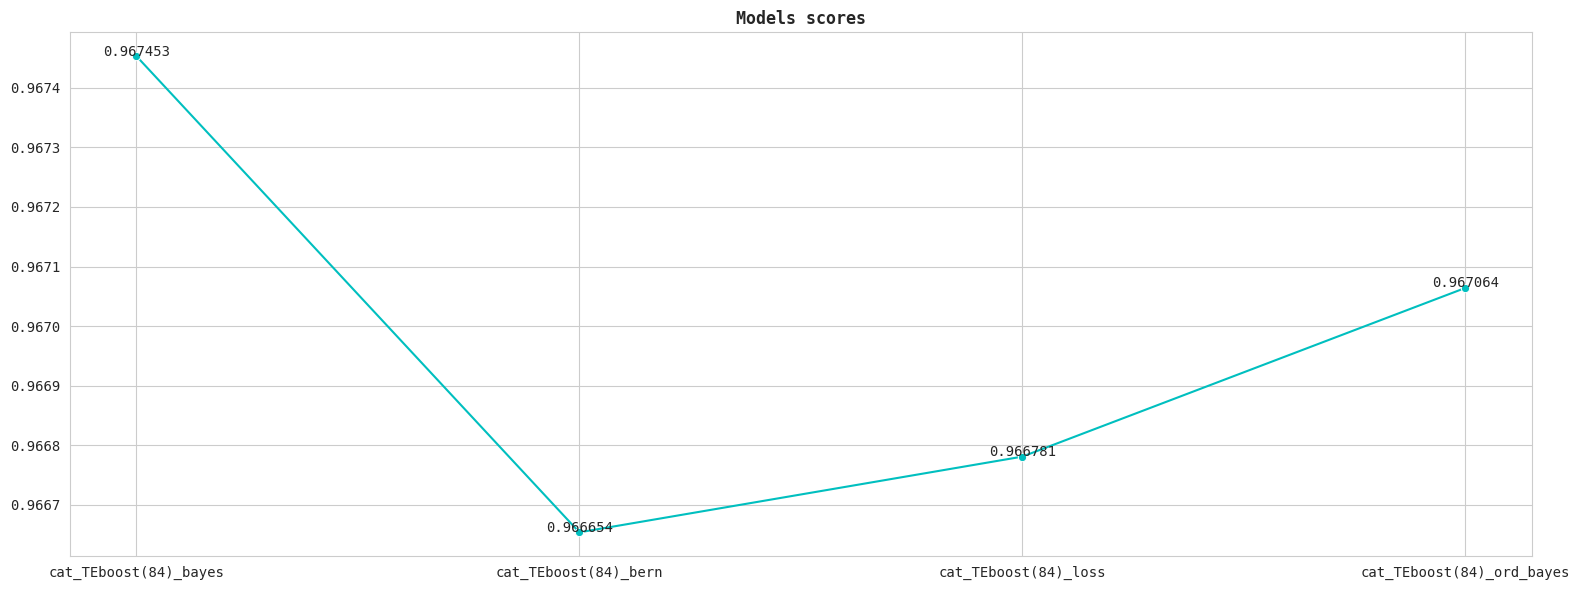

In [40]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

plt.tight_layout()
plt.show()

cat_TEboost(84)_bayes_967453 saved!


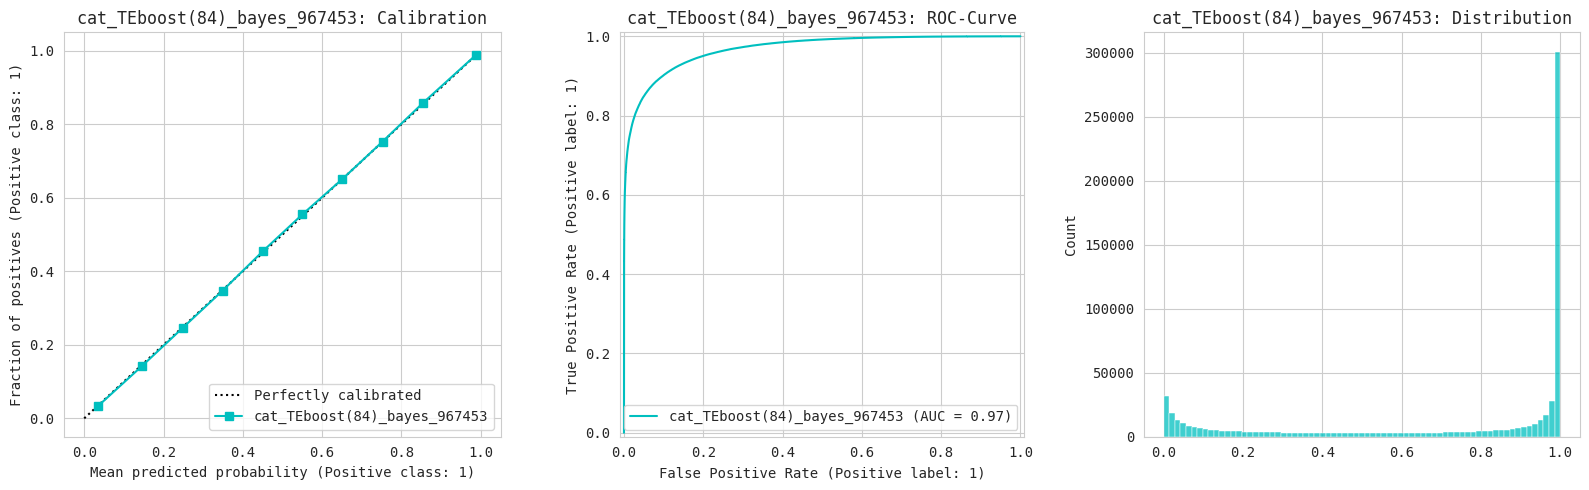


cat_TEboost(84)_bern_966654 saved!


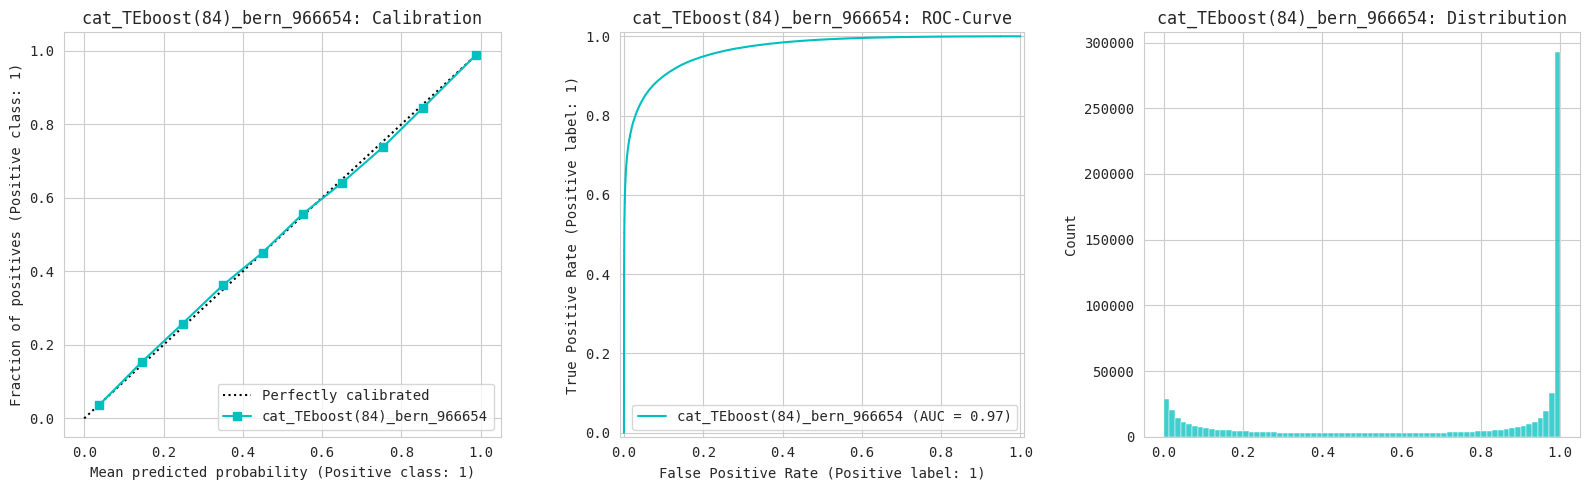


cat_TEboost(84)_loss_966781 saved!


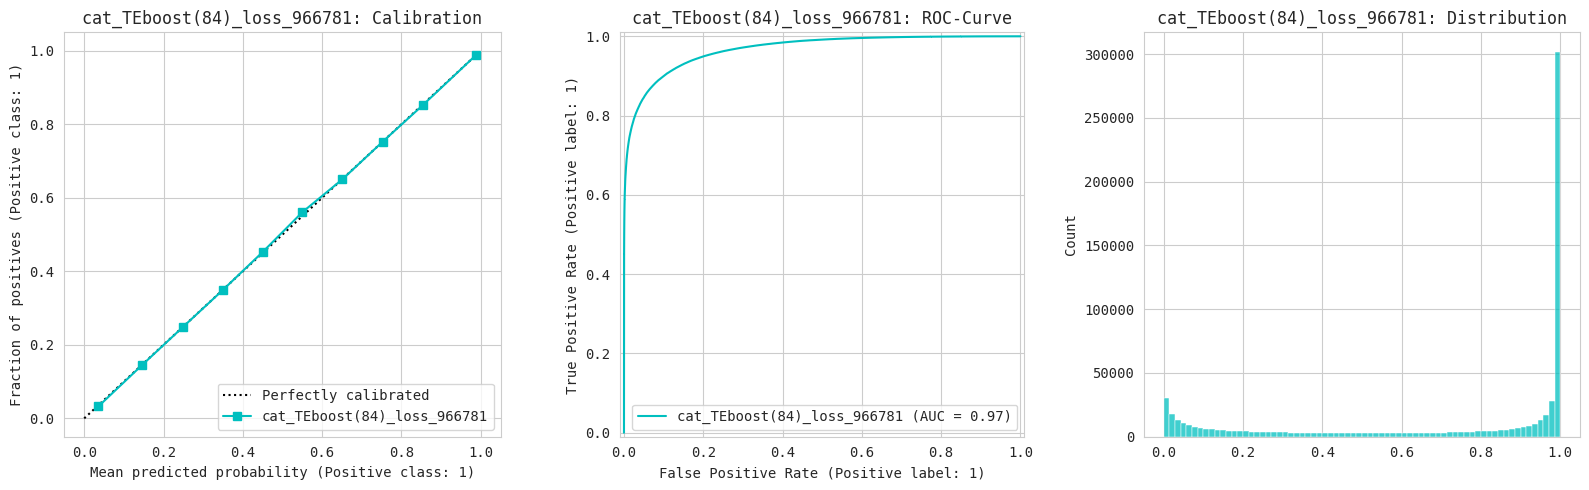


cat_TEboost(84)_ord_bayes_967064 saved!


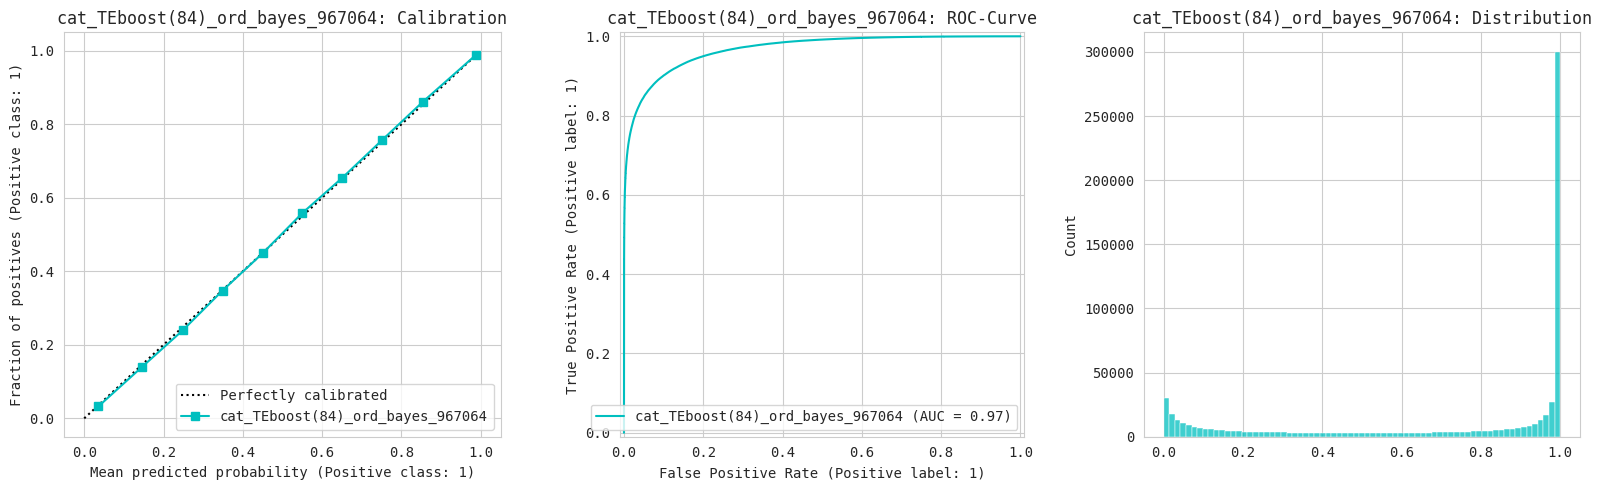

In [41]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [42]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

cat_TEboost(84)_bayes_967453 saved! (296302,)
cat_TEboost(84)_bern_966654 saved! (296302,)
cat_TEboost(84)_loss_966781 saved! (296302,)
cat_TEboost(84)_ord_bayes_967064 saved! (296302,)


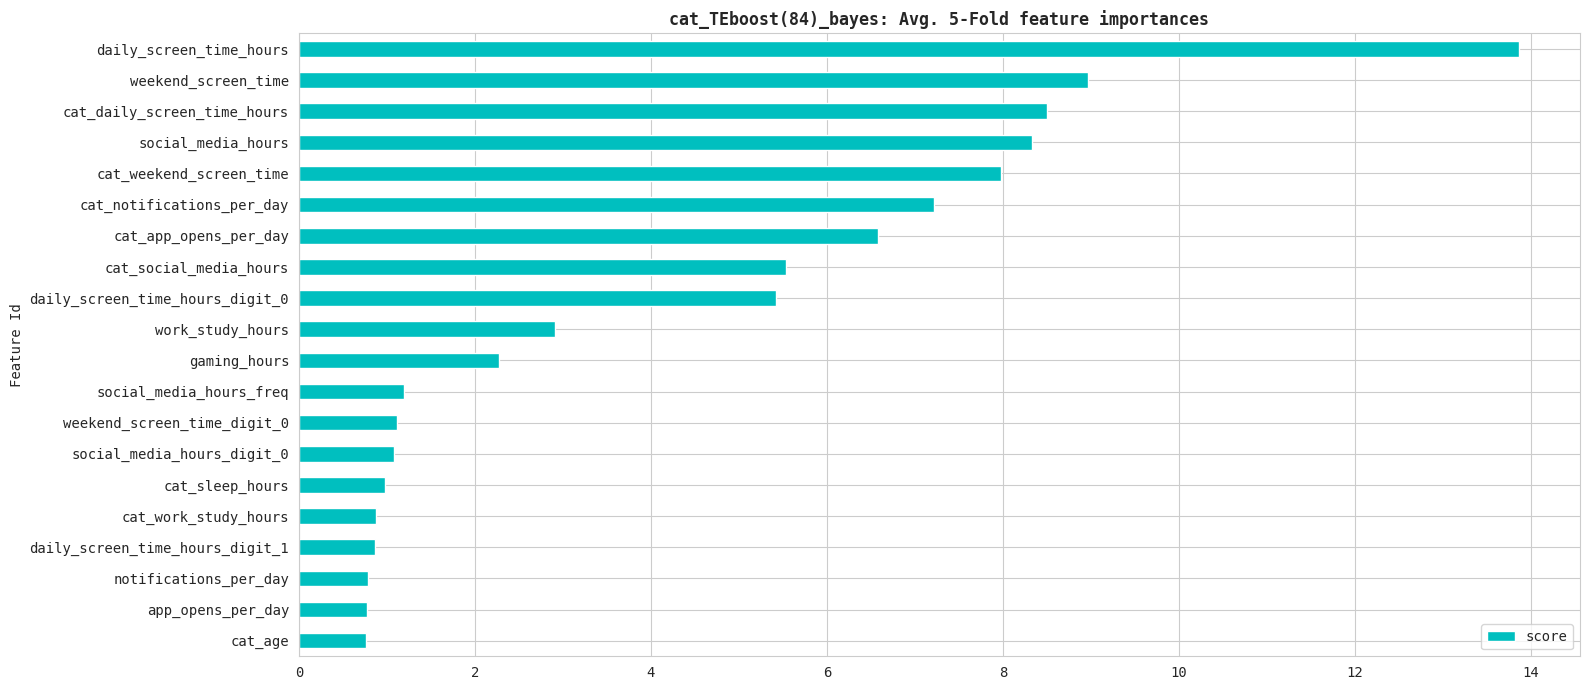

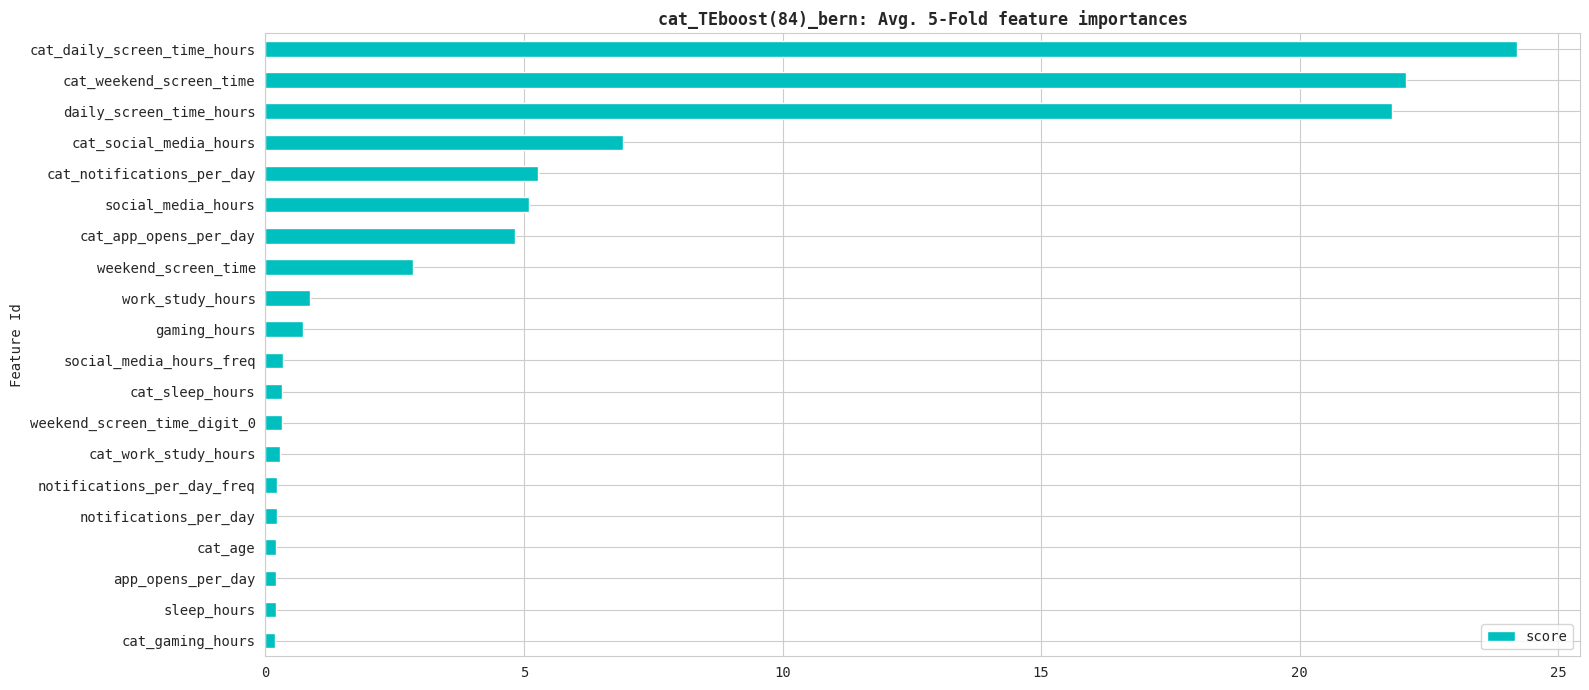

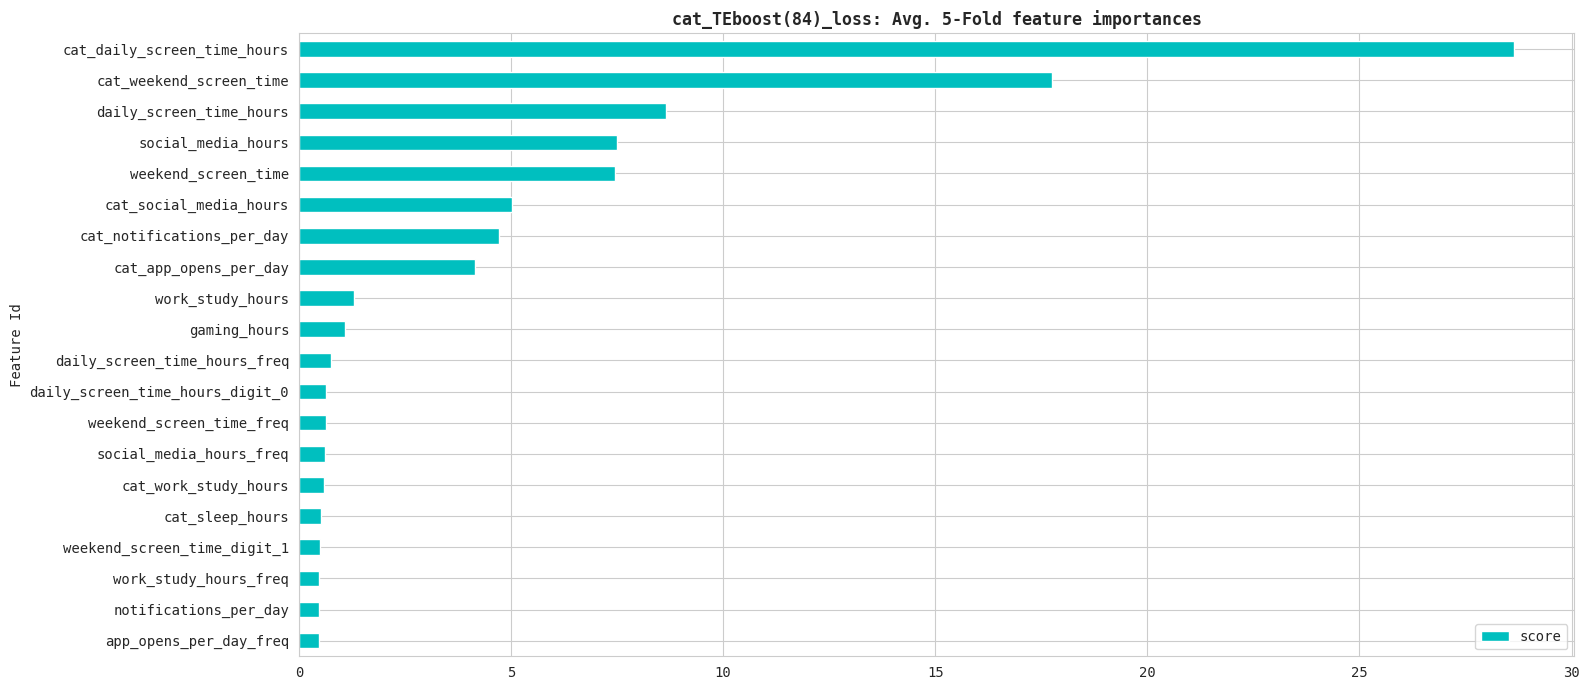

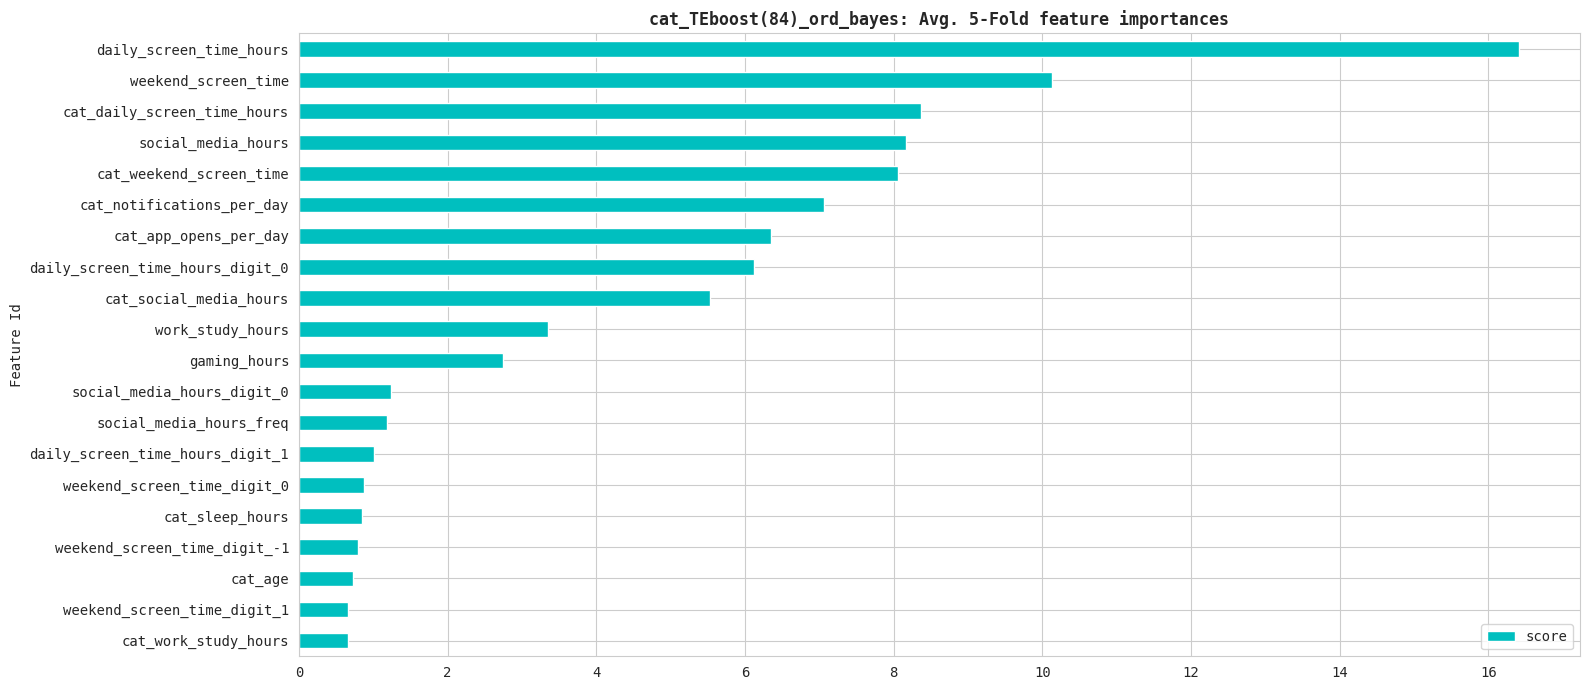

In [43]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_feat_importances[k] = y # np.mean(value, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

top_n = 20

for i, (m, df) in enumerate(all_feat_importances.items()):
    df_merge = df[0].merge(df[1], how="left", on="Feature Id", suffixes=("_0", ""))\
                    .merge(df[2], how="left", on="Feature Id", suffixes=("_1", ""))\
                    .merge(df[3], how="left", on="Feature Id", suffixes=("_2", ""))\
                    .merge(df[4], how="left", on="Feature Id", suffixes=("_3", "_4"))

    # display(df_merge.head())
    ## -------------------------------------------------------------------------------
    # df_merge["avg_score"] = df_merge.iloc[:, 1:].mean(axis=1)
    # df_merge.sort_values(by="avg_score").iloc[:, :top_n].plot.barh(y="avg_score", x="Feature Id", figsize=(18, 8))
    # plt.tight_layout()
    # plt.show()
    # print()
    ## -------------------------------------------------------------------------------
    df_final = pd.concat([df[0]["Feature Id"], df_merge.drop(columns=["Feature Id"])\
                                                       .mean(axis=1)], axis=1)\
                                                       .rename(columns={0: "score"})\
                                                       .sort_values(by="score")

    ax = df_final.tail(top_n).plot.barh(y="score", x="Feature Id", figsize=(16, 7))
    ax.set_title(f"{m}: Avg. {CFG['FOLDS']}-Fold feature importances", fontweight="semibold")
    plt.tight_layout()
    plt.show()
    print()

In [44]:
pd.DataFrame(model_results)

,cat_TEboost(84)_bayes_967453,cat_TEboost(84)_bern_966654,cat_TEboost(84)_loss_966781,cat_TEboost(84)_ord_bayes_967064
0,0.999336,0.999515,0.999301,0.999437
1,0.970164,0.969907,0.970083,0.975413
2,0.827294,0.876555,0.890196,0.835882
3,0.998383,0.995368,0.997369,0.997766
4,0.998857,0.996465,0.998087,0.998595
...,...,...,...,...
296297,0.999997,0.999976,1.000000,0.999999
296298,0.641023,0.617442,0.554090,0.645110
296299,0.168025,0.113002,0.142495,0.167441
296300,0.783323,0.748251,0.788875,0.829965


In [45]:
# !rm -r /kaggle/working